In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Create output directory for all saved files
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/images', exist_ok=True)
print(f"All output files will be saved to: {OUTPUT_DIR}/")

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

All output files will be saved to: output/
Using device: cuda


In [3]:
# Create directories for data
os.makedirs(f'{OUTPUT_DIR}/data/images', exist_ok=True)

In [4]:
def generate_house_image(row, image_size=256):
    """
    Generate a simple synthetic house image based on properties.
    """
    from PIL import Image, ImageDraw, ImageFont
    import numpy as np
    
    # Create base image with color based on neighborhood
    neighborhoods = ['Downtown', 'Suburbs', 'Waterfront', 'Historic', 'Modern']
    colors = {
        'Downtown': (200, 150, 100),
        'Suburbs': (100, 200, 100),
        'Waterfront': (100, 150, 200),
        'Historic': (180, 100, 80),
        'Modern': (150, 150, 150)
    }
    
    neighborhood = row['neighborhood']
    base_color = colors.get(neighborhood, (150, 150, 150))
    
    # Create image
    img = Image.new('RGB', (image_size, image_size), base_color)
    draw = ImageDraw.Draw(img)
    
    # Draw house structure
    house_width = int(image_size * 0.6)
    house_height = int(image_size * 0.5)
    house_x = (image_size - house_width) // 2
    house_y = int(image_size * 0.25)
    
    draw.rectangle(
        [house_x, house_y, house_x + house_width, house_y + house_height],
        fill=(180, 120, 80), outline=(100, 50, 0), width=2
    )
    
    # Draw roof
    roof_points = [
        (house_x, house_y),
        (house_x + house_width // 2, house_y - 40),
        (house_x + house_width, house_y)
    ]
    draw.polygon(roof_points, fill=(140, 80, 60))
    
    # Draw windows based on bedrooms
    bedrooms = int(row['bedrooms'])
    window_size = 20
    window_y = house_y + 30
    
    for i in range(min(bedrooms, 4)):
        window_x = house_x + 40 + i * 50
        draw.rectangle(
            [window_x, window_y, window_x + window_size, window_y + window_size],
            fill=(135, 206, 235), outline=(0, 0, 0), width=1
        )
    
    # Draw door
    door_width = 30
    door_height = 50
    door_x = house_x + house_width // 2 - door_width // 2
    door_y = house_y + house_height - door_height
    
    draw.rectangle(
        [door_x, door_y, door_x + door_width, door_y + door_height],
        fill=(101, 67, 33), outline=(0, 0, 0), width=1
    )
    
    # Add garage based on garage_size
    if row['garage_size'] > 0:
        garage_width = int(50 * min(row['garage_size'], 3) / 3)
        draw.rectangle(
            [house_x + house_width + 10, house_y + house_height - 40,
             house_x + house_width + 10 + garage_width, house_y + house_height],
            fill=(140, 140, 140), outline=(0, 0, 0), width=1
        )
    
    return img

# Generate synthetic dataset
np.random.seed(42)
n_samples = 1000

neighborhoods = ['Downtown', 'Suburbs', 'Waterfront', 'Historic', 'Modern']
data = {
    'price': np.random.normal(250000, 100000, n_samples).astype(int),
    'square_feet': np.random.normal(2000, 500, n_samples).astype(int),
    'bedrooms': np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.15, 0.3, 0.35, 0.15, 0.05]),
    'bathrooms': np.random.choice([1, 2, 3, 4], n_samples, p=[0.25, 0.45, 0.25, 0.05]),
    'age': np.random.uniform(0, 100, n_samples),
    'garage_size': np.random.choice([0, 1, 2, 3], n_samples, p=[0.2, 0.4, 0.3, 0.1]),
    'lot_size': np.random.uniform(2000, 10000, n_samples),
    'condition': np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.05, 0.1, 0.3, 0.35, 0.2]),
    'neighborhood': np.random.choice(neighborhoods, n_samples)
}

df = pd.DataFrame(data)

# Adjust price based on features (to make prediction meaningful)
df['price'] = (
    150000 + 
    df['square_feet'] * 100 + 
    df['bedrooms'] * 25000 + 
    df['bathrooms'] * 15000 - 
    df['age'] * 500 + 
    df['garage_size'] * 5000 + 
    df['lot_size'] * 5 + 
    df['condition'] * 10000 +
    np.random.normal(0, 20000, n_samples)
).astype(int)

print(f"Generated dataset with {len(df)} samples")
print(f"\nDataset statistics:")
print(df.describe())

Generated dataset with 1000 samples

Dataset statistics:
              price  square_feet     bedrooms    bathrooms          age  \
count    1000.00000  1000.000000  1000.000000  1000.000000  1000.000000   
mean   495556.92500  2034.929000     2.641000     2.043000    49.869220   
std     66124.25133   498.722614     1.065483     0.802368    28.815271   
min    265947.00000   529.000000     1.000000     1.000000     0.022704   
25%    452312.00000  1696.750000     2.000000     1.000000    25.227927   
50%    498076.00000  2031.000000     3.000000     2.000000    48.367915   
75%    541504.25000  2363.750000     3.000000     3.000000    75.180491   
max    698200.00000  3596.000000     5.000000     4.000000    99.879294   

       garage_size     lot_size    condition  
count  1000.000000  1000.000000  1000.000000  
mean      1.300000  5893.131614     3.496000  
std       0.924584  2274.930645     1.084048  
min       0.000000  2001.928037     1.000000  
25%       1.000000  3933.286453 

Generating synthetic house images...
  Generated 200/1000 images...
  Generated 400/1000 images...
  Generated 600/1000 images...
  Generated 800/1000 images...
  Generated 1000/1000 images...

Generated 1000 images in output/data/images/


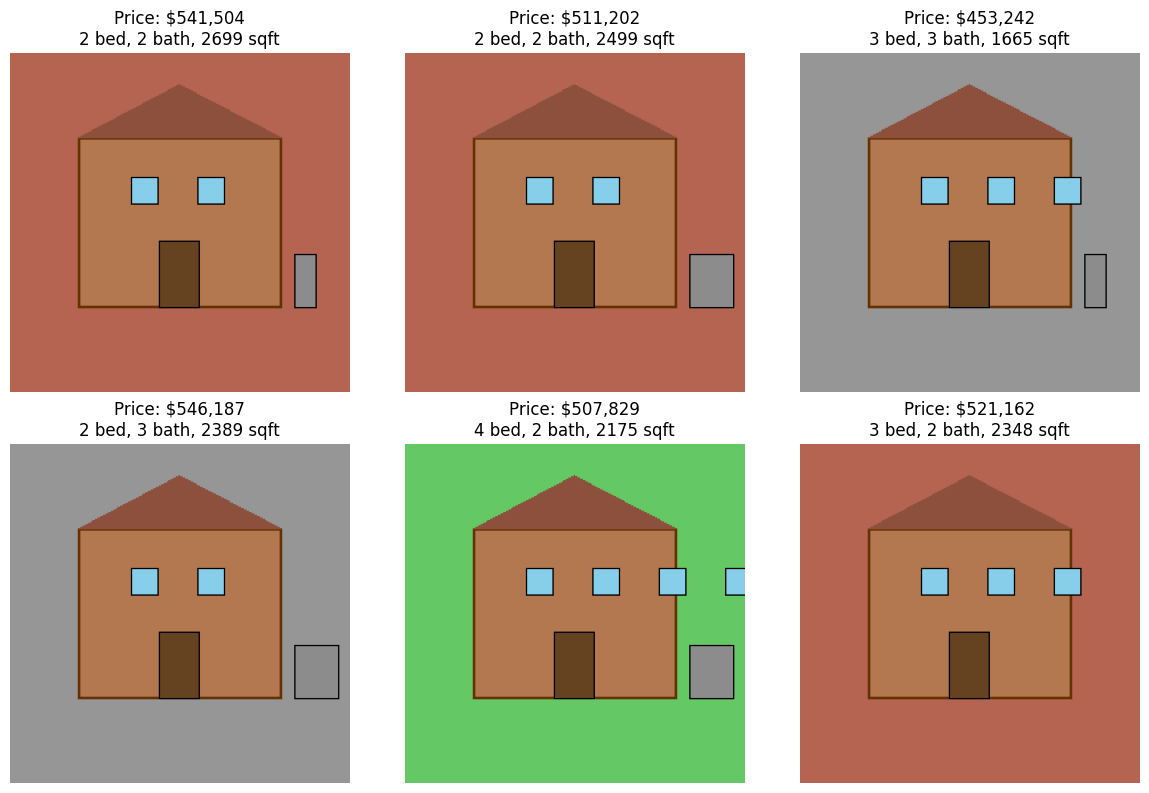

Sample images saved to output/sample_houses.png


In [5]:
# Generate images for all samples
print("Generating synthetic house images...")
image_paths = []
for idx, row in df.iterrows():
    img = generate_house_image(row)
    img_path = f'{OUTPUT_DIR}/data/images/house_{idx:04d}.png'
    img.save(img_path)
    image_paths.append(img_path)
    
    if (idx + 1) % 200 == 0:
        print(f"  Generated {idx + 1}/{len(df)} images...")

df['image_path'] = image_paths
print(f"\nGenerated {len(image_paths)} images in {OUTPUT_DIR}/data/images/")

# Display a few sample images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, idx in enumerate([0, 100, 300, 500, 700, 900]):
    row = df.iloc[idx]
    img = Image.open(row['image_path'])
    axes[i].imshow(img)
    axes[i].set_title(f"Price: ${row['price']:,}\n{row['bedrooms']} bed, {row['bathrooms']} bath, {row['square_feet']} sqft")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sample_houses.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Sample images saved to {OUTPUT_DIR}/sample_houses.png")

In [6]:
# Define features
numerical_features = ['square_feet', 'bedrooms', 'bathrooms', 'age', 'garage_size', 'lot_size', 'condition']
categorical_features = ['neighborhood']
target = 'price'

# Split data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

# Create preprocessor for tabular data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# Fit preprocessor on training data
X_train_num = train_df[numerical_features + categorical_features]
y_train = train_df[target].values

X_train_processed = preprocessor.fit_transform(X_train_num)
print(f"\nProcessed tabular features shape: {X_train_processed.shape}")
print(f"Feature names: {numerical_features + ['neighborhood_' + x for x in preprocessor.named_transformers_['cat'].get_feature_names_out(['neighborhood'])]}")

Training samples: 640
Validation samples: 160
Test samples: 200

Processed tabular features shape: (640, 11)
Feature names: ['square_feet', 'bedrooms', 'bathrooms', 'age', 'garage_size', 'lot_size', 'condition', 'neighborhood_neighborhood_Historic', 'neighborhood_neighborhood_Modern', 'neighborhood_neighborhood_Suburbs', 'neighborhood_neighborhood_Waterfront']


In [7]:
class MultimodalHousingDataset(Dataset):
    """
    Custom Dataset for multimodal housing data (images + tabular).
    """
    
    def __init__(self, df, preprocessor, numerical_features, categorical_features, target, img_size=224):
        self.df = df.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.numerical_features = numerical_features
        self.categorical_features = categorical_features
        self.target = target
        self.img_size = img_size
        
        # Image transforms
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load and transform image
        image = Image.open(row['image_path']).convert('RGB')
        image = self.transform(image)
        
        # Process tabular features
        tabular_data = row[self.numerical_features + self.categorical_features]
        tabular_data = pd.DataFrame([tabular_data])
        tabular = self.preprocessor.transform(tabular_data)
        tabular = torch.FloatTensor(tabular[0])
        
        # Get target
        price = torch.FloatTensor([row[self.target]])[0]
        
        return image, tabular, price

# Create datasets
train_dataset = MultimodalHousingDataset(
    train_df, preprocessor, numerical_features, categorical_features, target
)
val_dataset = MultimodalHousingDataset(
    val_df, preprocessor, numerical_features, categorical_features, target
)
test_dataset = MultimodalHousingDataset(
    test_df, preprocessor, numerical_features, categorical_features, target
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Verify a batch
images, tabular, prices = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Images: {images.shape}")
print(f"  Tabular: {tabular.shape}")
print(f"  Prices: {prices.shape}")

Train dataset size: 640
Validation dataset size: 160
Test dataset size: 200

Batch shapes:
  Images: torch.Size([32, 3, 224, 224])
  Tabular: torch.Size([32, 11])
  Prices: torch.Size([32])


In [8]:
class MultimodalHousingModel(nn.Module):
    """
    Multimodal model that combines CNN image features with tabular data.
    
    Architecture:
    - Image branch: Pretrained ResNet18 (without final layer) -> 512 features
    - Tabular branch: MLP -> 64 features
    - Fusion: Concatenate -> FC layers -> Price prediction
    """
    
    def __init__(self, tabular_input_size, dropout=0.3):
        super(MultimodalHousingModel, self).__init__()
        
        # Image branch: Use pretrained ResNet18
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Remove the final fully connected layer
        self.image_encoder = nn.Sequential(*list(resnet.children())[:-1])
        self.image_features_size = 512  # ResNet18 outputs 512 features
        
        # Tabular branch: MLP for processing structured data
        self.tabular_mlp = nn.Sequential(
            nn.Linear(tabular_input_size, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout)
        )
        self.tabular_features_size = 64
        
        # Fusion layer: Combine image and tabular features
        combined_features_size = self.image_features_size + self.tabular_features_size
        self.fusion = nn.Sequential(
            nn.Linear(combined_features_size, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout)
        )
        
        # Regression head: Output single price prediction
        self.regression_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, image, tabular):
        # Extract image features
        image_features = self.image_encoder(image)  # [batch, 512, 1, 1]
        image_features = image_features.view(image_features.size(0), -1)  # [batch, 512]
        
        # Process tabular features
        tabular_features = self.tabular_mlp(tabular)  # [batch, 64]
        
        # Concatenate features
        combined = torch.cat([image_features, tabular_features], dim=1)  # [batch, 576]
        
        # Fusion layers
        fused = self.fusion(combined)
        
        # Regression head
        price_pred = self.regression_head(fused)
        
        return price_pred.squeeze()

# Calculate tabular input size
tabular_input_size = X_train_processed.shape[1]
print(f"Tabular input size: {tabular_input_size}")

# Initialize model
model = MultimodalHousingModel(tabular_input_size=tabular_input_size)
model = model.to(device)
print("\nModel Architecture:")
print(model)

Tabular input size: 11

Model Architecture:
MultimodalHousingModel(
  (image_encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64

In [9]:
# Loss function and optimizer
criterion = nn.MSELoss()

# Use different learning rates for pretrained vs new layers
optimizer = optim.Adam([
    {'params': model.image_encoder.parameters(), 'lr': 1e-5},  # Lower LR for pretrained
    {'params': model.tabular_mlp.parameters(), 'lr': 1e-3},
    {'params': model.fusion.parameters(), 'lr': 1e-3},
    {'params': model.regression_head.parameters(), 'lr': 1e-3}
], weight_decay=1e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"Loss function: {criterion}")
print(f"Optimizer: Adam with differential learning rates")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Loss function: MSELoss()
Optimizer: Adam with differential learning rates
Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [10]:
# Training loop
num_epochs = 50
patience = 10
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []

model.train()
for epoch in range(num_epochs):
    # Training phase
    train_loss = 0.0
    for images, tabular, prices in train_loader:
        images = images.to(device)
        tabular = tabular.to(device)
        prices = prices.to(device)
        
        # Forward pass
        predictions = model(images, tabular)
        loss = criterion(predictions, prices)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * prices.size(0)
    
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, tabular, prices in val_loader:
            images = images.to(device)
            tabular = tabular.to(device)
            prices = prices.to(device)
            
            predictions = model(images, tabular)
            loss = criterion(predictions, prices)
            val_loss += loss.item() * prices.size(0)
    
    val_loss /= len(val_dataset)
    val_losses.append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), f'{OUTPUT_DIR}/best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    model.train()

Epoch 5/50 - Train Loss: 250657084211.2000, Val Loss: 250320807526.4000
Epoch 10/50 - Train Loss: 250353353523.2000, Val Loss: 249969885184.0000
Epoch 15/50 - Train Loss: 249568043827.2000, Val Loss: 249116121497.6000
Epoch 20/50 - Train Loss: 248051785728.0000, Val Loss: 247519884083.2000
Epoch 25/50 - Train Loss: 245573578752.0000, Val Loss: 245015651942.4000
Epoch 30/50 - Train Loss: 242142132633.6000, Val Loss: 241434820608.0000
Epoch 35/50 - Train Loss: 237658911539.2000, Val Loss: 236532472217.6000
Epoch 40/50 - Train Loss: 231761693081.6000, Val Loss: 230578346393.6000
Epoch 45/50 - Train Loss: 224834210201.6000, Val Loss: 223831520051.2000
Epoch 50/50 - Train Loss: 216579735552.0000, Val Loss: 215408145203.2000


In [11]:
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Training history plot saved to {OUTPUT_DIR}/training_history.png")

<Figure size 640x480 with 0 Axes>

Training history plot saved to output/training_history.png


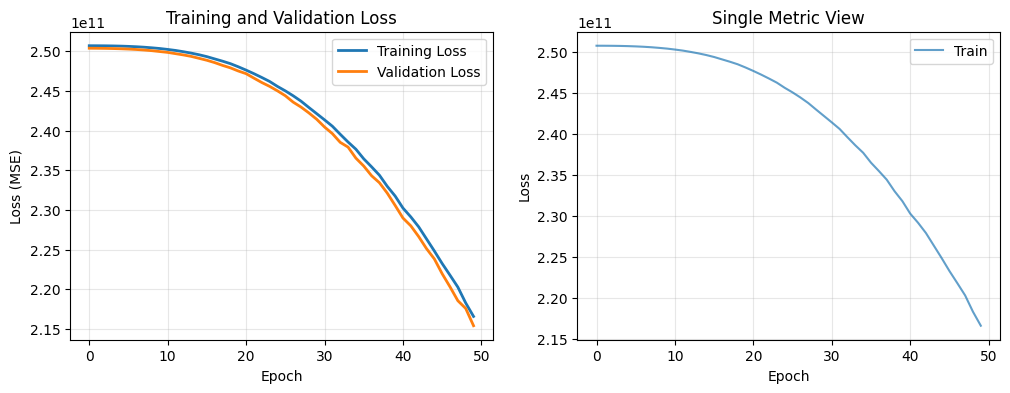

In [12]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Training Loss', linewidth=2)
axes[0].plot(val_losses, label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Learning rates over time (approximate)
axes[1].plot(train_losses, label='Train', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Single Metric View')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

In [13]:
# Load best model if it exists, otherwise use current model
model_path = f'{OUTPUT_DIR}/best_model.pth'
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Loaded best model from checkpoint")
else:
    print(f"Model checkpoint not found at {model_path}, using current model")
    # Ensure output directory exists and save current model
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    torch.save(model.state_dict(), model_path)
    print(f"Saved current model to {model_path}")

Loaded best model from checkpoint


In [14]:
# Evaluate on test set
model.eval()
test_targets = []
test_predictions = []
errors = []

with torch.no_grad():
    for images, tabular, prices in test_loader:
        images = images.to(device)
        tabular = tabular.to(device)
        
        predictions = model(images, tabular)
        
        test_targets.extend(prices.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())

test_targets = np.array(test_targets)
test_predictions = np.array(test_predictions)
errors = test_predictions - test_targets

# Calculate metrics
mae = mean_absolute_error(test_targets, test_predictions)
mse = mean_squared_error(test_targets, test_predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test_targets - test_predictions) / test_targets)) * 100

print(f"\n{'='*50}")
print(f"TEST SET PERFORMANCE")
print(f"{'='*50}")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


TEST SET PERFORMANCE
Mean Absolute Error (MAE): $456,272.09
Root Mean Squared Error (RMSE): $460,735.96
Mean Absolute Percentage Error (MAPE): 92.52%


In [15]:
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Prediction analysis plot saved to {OUTPUT_DIR}/prediction_analysis.png")

<Figure size 640x480 with 0 Axes>

Prediction analysis plot saved to output/prediction_analysis.png


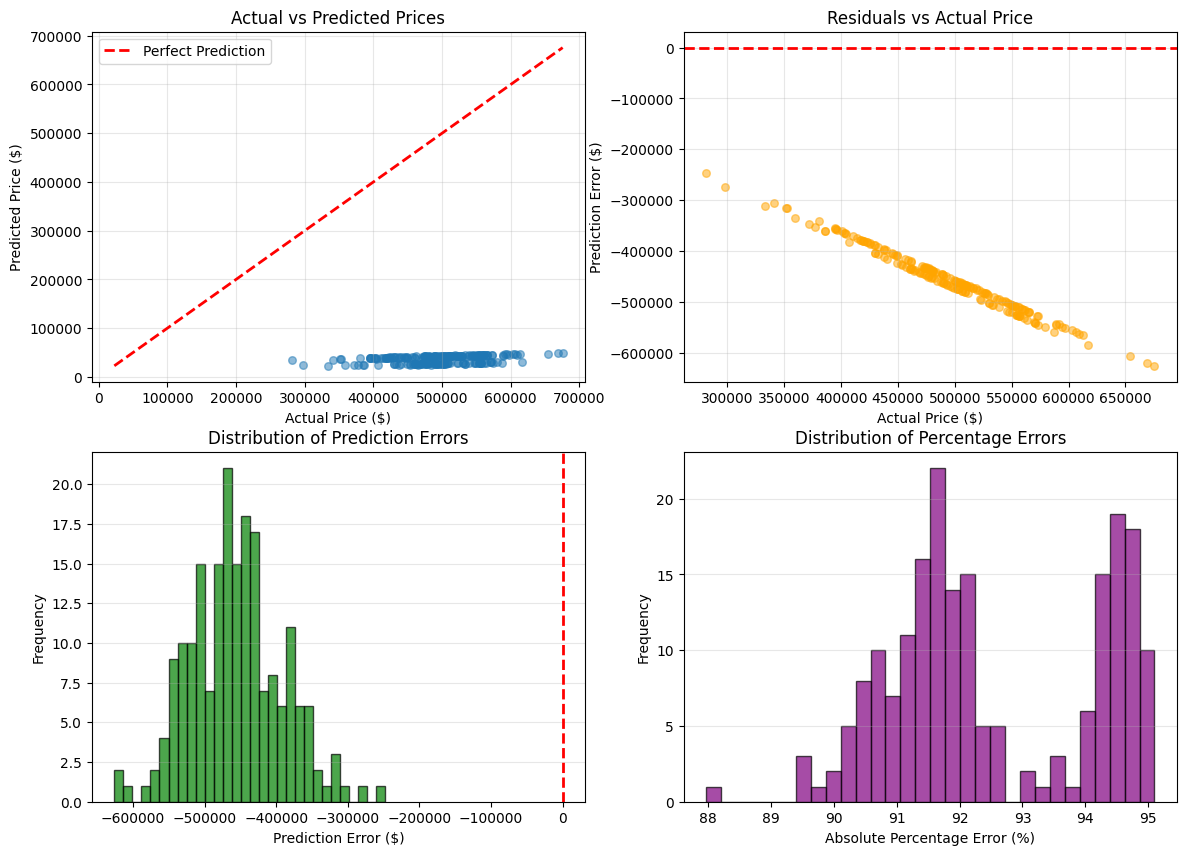

In [16]:
# Visualize predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted scatter plot
axes[0, 0].scatter(test_targets, test_predictions, alpha=0.5, s=30)
min_val = min(test_targets.min(), test_predictions.min())
max_val = max(test_targets.max(), test_predictions.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price ($)')
axes[0, 0].set_ylabel('Predicted Price ($)')
axes[0, 0].set_title('Actual vs Predicted Prices')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals scatter plot
axes[0, 1].scatter(test_targets, errors, alpha=0.5, s=30, color='orange')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Actual Price ($)')
axes[0, 1].set_ylabel('Prediction Error ($)')
axes[0, 1].set_title('Residuals vs Actual Price')
axes[0, 1].grid(True, alpha=0.3)

# 3. Error histogram
axes[1, 0].hist(errors, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Prediction Error ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Prediction Errors')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Percentage error distribution
percent_errors = np.abs(errors / test_targets * 100)
axes[1, 1].hist(percent_errors, bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Absolute Percentage Error (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Percentage Errors')
axes[1, 1].grid(True, alpha=0.3, axis='y')

In [17]:
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Error distribution plot saved to {OUTPUT_DIR}/error_distribution.png")

<Figure size 640x480 with 0 Axes>

Error distribution plot saved to output/error_distribution.png


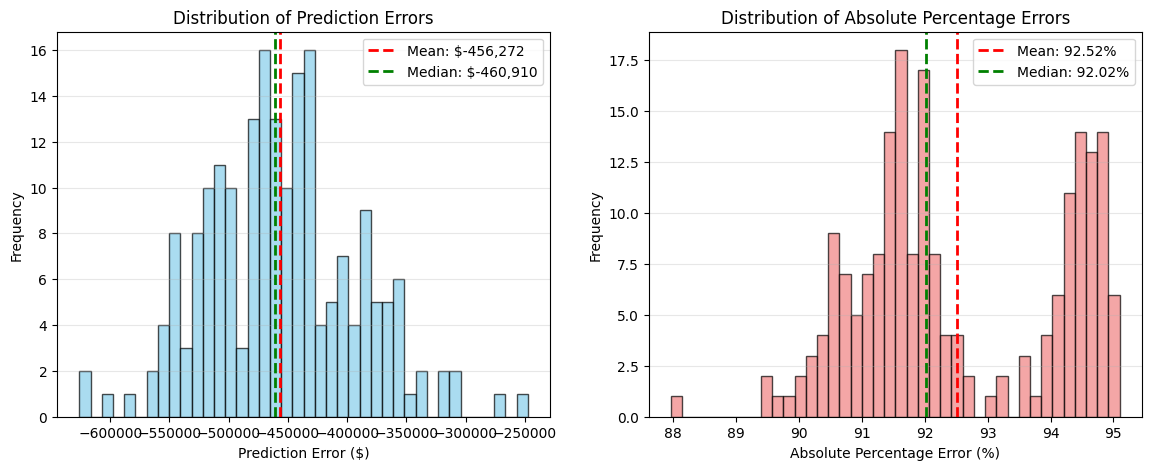

In [18]:
# Error analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
axes[0].hist(errors, bins=40, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(x=errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${errors.mean():,.0f}')
axes[0].axvline(x=np.median(errors), color='green', linestyle='--', linewidth=2, label=f'Median: ${np.median(errors):,.0f}')
axes[0].set_xlabel('Prediction Error ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Prediction Errors')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Absolute percentage error distribution
abs_pct_error = np.abs(errors / test_targets) * 100
axes[1].hist(abs_pct_error, bins=40, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].axvline(x=abs_pct_error.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {abs_pct_error.mean():.2f}%')
axes[1].axvline(x=np.median(abs_pct_error), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(abs_pct_error):.2f}%')
axes[1].set_xlabel('Absolute Percentage Error (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Absolute Percentage Errors')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

In [19]:
# Create predictions DataFrame
predictions_df = pd.DataFrame({
    'actual_price': test_targets,
    'predicted_price': test_predictions,
    'absolute_error': errors,
    'percent_error': np.abs(errors / np.array(test_targets) * 100)
})

# Add some features for context
predictions_df = predictions_df.reset_index(drop=True)
test_df_reset = test_df.reset_index(drop=True)
predictions_df['square_feet'] = test_df_reset['square_feet']
predictions_df['bedrooms'] = test_df_reset['bedrooms']
predictions_df['neighborhood'] = test_df_reset['neighborhood']

# Display best and worst predictions
print("=" * 70)
print("TOP 5 MOST ACCURATE PREDICTIONS")
print("=" * 70)
best_preds = predictions_df.nsmallest(5, 'absolute_error')
for idx, row in best_preds.iterrows():
    print(f"\nActual: ${row['actual_price']:,.0f} | Predicted: ${row['predicted_price']:,.0f}")
    print(f"  Error: ${row['absolute_error']:,.0f} ({row['percent_error']:.2f}%)")
    print(f"  {row['bedrooms']} bed, {row['square_feet']} sqft, {row['neighborhood']}")

print("\n" + "=" * 70)
print("TOP 5 LEAST ACCURATE PREDICTIONS")
print("=" * 70)
worst_preds = predictions_df.nlargest(5, 'absolute_error')
for idx, row in worst_preds.iterrows():
    print(f"\nActual: ${row['actual_price']:,.0f} | Predicted: ${row['predicted_price']:,.0f}")
    print(f"  Error: ${row['absolute_error']:,.0f} ({row['percent_error']:.2f}%)")
    print(f"  {row['bedrooms']} bed, {row['square_feet']} sqft, {row['neighborhood']}")

TOP 5 MOST ACCURATE PREDICTIONS

Actual: $675,510 | Predicted: $49,585
  Error: $-625,925 (92.66%)
  4 bed, 2760 sqft, Historic

Actual: $668,946 | Predicted: $49,500
  Error: $-619,446 (92.60%)
  4 bed, 3294 sqft, Suburbs

Actual: $653,599 | Predicted: $47,700
  Error: $-605,898 (92.70%)
  3 bed, 3078 sqft, Suburbs

Actual: $616,909 | Predicted: $31,275
  Error: $-585,634 (94.93%)
  3 bed, 3037 sqft, Modern

Actual: $613,089 | Predicted: $47,332
  Error: $-565,757 (92.28%)
  3 bed, 2687 sqft, Historic

TOP 5 LEAST ACCURATE PREDICTIONS

Actual: $281,349 | Predicted: $33,847
  Error: $-247,502 (87.97%)
  1 bed, 1066 sqft, Downtown

Actual: $297,885 | Predicted: $23,677
  Error: $-274,208 (92.05%)
  2 bed, 1280 sqft, Waterfront

Actual: $341,268 | Predicted: $35,558
  Error: $-305,710 (89.58%)
  1 bed, 923 sqft, Downtown

Actual: $333,467 | Predicted: $22,747
  Error: $-310,720 (93.18%)
  2 bed, 939 sqft, Modern

Actual: $351,521 | Predicted: $36,840
  Error: $-314,681 (89.52%)
  2 bed, 

In [20]:
# Ablation study: Compare model with images only, tabular only, and both
print("\n" + "="*70)
print("ABLATION STUDY: Component Importance Analysis")
print("="*70)

class ImageOnlyModel(nn.Module):
    def __init__(self):
        super(ImageOnlyModel, self).__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.image_encoder = nn.Sequential(*list(resnet.children())[:-1])
        self.head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
    
    def forward(self, image, tabular=None):
        features = self.image_encoder(image)
        features = features.view(features.size(0), -1)
        return self.head(features).squeeze()

class TabularOnlyModel(nn.Module):
    def __init__(self, tabular_input_size):
        super(TabularOnlyModel, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(tabular_input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, image, tabular):
        return self.mlp(tabular).squeeze()

# Test models
models_to_test = {
    'Full Model': model,
    'Image Only': ImageOnlyModel().to(device),
    'Tabular Only': TabularOnlyModel(tabular_input_size).to(device)
}

ablation_results = {}

for model_name, test_model in models_to_test.items():
    test_model.eval()
    preds = []
    with torch.no_grad():
        for images, tabular, prices in test_loader:
            images = images.to(device)
            tabular = tabular.to(device)
            pred = test_model(images, tabular)
            preds.extend(pred.cpu().numpy())
    
    preds = np.array(preds)
    mae = mean_absolute_error(test_targets, preds)
    rmse = np.sqrt(mean_squared_error(test_targets, preds))
    mape = np.mean(np.abs((test_targets - preds) / test_targets)) * 100
    
    ablation_results[model_name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
    print(f"\n{model_name}:")
    print(f"  MAE: ${mae:,.2f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  MAPE: {mape:.2f}%")


ABLATION STUDY: Component Importance Analysis

Full Model:
  MAE: $456,272.09
  RMSE: $460,735.96
  MAPE: 92.52%

Image Only:
  MAE: $492,751.53
  RMSE: $497,141.92
  MAPE: 100.00%

Tabular Only:
  MAE: $492,751.91
  RMSE: $497,142.31
  MAPE: 100.00%


In [21]:
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Ablation study plot saved to {OUTPUT_DIR}/ablation_study.png")

<Figure size 640x480 with 0 Axes>

Ablation study plot saved to output/ablation_study.png


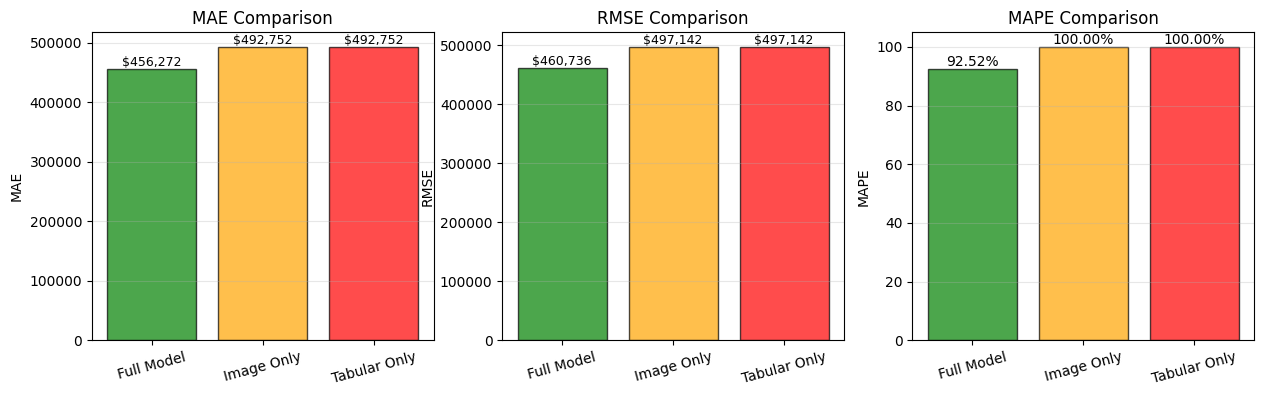

In [22]:
# Visualize ablation study results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['MAE', 'RMSE', 'MAPE']
model_names = list(ablation_results.keys())

for idx, metric in enumerate(metrics):
    values = [ablation_results[model][metric] for model in model_names]
    colors = ['green', 'orange', 'red']
    
    axes[idx].bar(model_names, values, color=colors, alpha=0.7, edgecolor='black')
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(f'{metric} Comparison')
    axes[idx].tick_params(axis='x', rotation=15)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, v in enumerate(values):
        if metric == 'MAPE':
            axes[idx].text(i, v, f'{v:.2f}%', ha='center', va='bottom')
        else:
            axes[idx].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

In [23]:
print(f"\n📁 OUTPUT FILES (all saved to {OUTPUT_DIR}/)")
print(f"   - best_model.pth: Trained model weights")
print(f"   - training_history.png: Training curves")
print(f"   - prediction_analysis.png: Actual vs Predicted plots")
print(f"   - error_distribution.png: Error analysis")
print(f"   - ablation_study.png: Model comparison")
print(f"   - sample_houses.png: Sample synthetic images")
print(f"   - data/images/: All generated house images")


📁 OUTPUT FILES (all saved to output/)
   - best_model.pth: Trained model weights
   - training_history.png: Training curves
   - prediction_analysis.png: Actual vs Predicted plots
   - error_distribution.png: Error analysis
   - ablation_study.png: Model comparison
   - sample_houses.png: Sample synthetic images
   - data/images/: All generated house images
